In [3]:
#import minimo propuesto:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import urllib
import seaborn as sns
import pandas as pd
import scipy.sparse as sparse

## P1: Elección y descripción de la red


Se escogió la red de transacciones de Bitcoin OTC (http://konect.cc/networks/soc-sign-bitcoinotc/)  
Bitcoin OTC (https://bitcoin-otc.com/) es una plataforma en línea que facilita el comercio directo de Bitcoins entre personas, operando al margen de plataformas de intercambio centralizadas, como Binance o Coinbase.
* **Contexto de recopilación:** Dado que las transacciones de Bitcoin son anónimas, la plataforma implementó un sistema de reputación ("web of trust"). **citar el link donde esta ubicada la base de datos de la web of trust**
* **Por qué se escogieron los datos:** A diferencia de las redes convencionales, esta es una red dirigida y ponderada (las conexiones poseen un valor numérico que mide la intensidad de la relación). Además, es una red con signo, que documenta tanto el nivel de confianza como desconfianza. Esto permite usar PageRank para rastrear estructuras criminales en lugar de solo medir popularidad.
* **Qué representan los nodos:** Cada nodo representa a un usuario individual (comprador o vendedor) registrado en la plataforma.
* **Qué representan las aristas:** Las aristas representan la evaluación de un usuario sobre otro. Al ser dirigidas, muestran la dirección de la acción (el usuario A evalúa al usuario B). Al ser ponderadas, asignan una magnitud a esa relación, utilizando una escala del -10 (estafa/desconfianza total) al +10 (confianza total). También incluyen la marca de tiempo exacta de la calificación.  

| Estadística | Fórmula / Símbolo | Valor (Bitcoin OTC) |
| --- | --- | --- |
| **Número de nodos** | $n$ | 5,881 |
| **Número de aristas** | $m$ | 35,592 |
| **Grado de entrada medio** | $\bar{d}^{\text{in}}$ | 6.05 |
| **Grado de salida medio** | $\bar{d}^{\text{out}}$ | 6.05 |
| **Nodo de mayor grado de entrada** | - | [ID del Nodo a calcular] |
| **Densidad de la red** | $\frac{m}{n(n-1)}$ | 0.001029 |
| **Cantidad de nodos colgantes** (sin aristas de salida) | - | [Cantidad a calcular] |

*(Nota: En una red dirigida, el grado de entrada medio y el grado de salida medio son iguales, ya que cada arista que sale de un nodo entra necesariamente en otro. La densidad se calculó asumiendo el máximo de conexiones posibles sin contar bucles).*

## P2

**Pregunta:**
¿Es posible identificar a los cabecillas o actores centrales del fraude dentro de una plataforma de transacciones anónimas aplicando el algoritmo de PageRank de manera inversa sobre las interacciones de máxima desconfianza?

**Hipótesis:**
Nuestra hipótesis plantea que los estafadores sofisticados en la red Bitcoin OTC no operan de forma aislada, sino que interactúan y se califican negativamente entre sí para fingir legitimidad y distanciarse. Por lo tanto, al aislar los pesos negativos de la red e invertir la dirección de las aristas, un cálculo de PageRank revelará una jerarquía oculta donde los nodos con mayor "rango de desconfianza" corresponderán a los mayores estafadores o ejes centrales del submundo criminal en la plataforma.

## Seccion p3

Hacer analisis (propuesta, usar las clases como referente), lo que se nos pide es:


(a) Gr´afico de la distribuci´on del grado de entrada y del grado de salida.
(b) Identificaci´on y conteo de los nodos colgantes (nodos con grado de salida
cero). Expliquen por qu´e su presencia es problem´atica para el PageRank y
c´omo se resuelve con la matriz columna-estoc´astica S.
(c) Gr´afico o tabla con los 10 nodos de mayor grado de entrada y los 10 nodos de
mayor grado de salida. Si los nodos tienen nombres o etiquetas, incl´uyanlos.
(d) Comentario sobre si la red parece ser fuertemente conexa o si existen com-
ponentes aisladas. Pueden usar la condici´on de que la Matriz de Google G
es siempre irreducible independientemente de la estructura del grafo subya-
cente


## a ) Grafico de la distribucion del grado de entrada y del grado de salida

In [4]:
#abrir el grafo

RUTA_GRAFO = "grafo/soc-sign-bitcoinotc/out.soc-sign-bitcoinotc"
G = nx.read_edgelist(RUTA_GRAFO , create_using=nx.DiGraph() , comments= "%" , data=[('weight', float), ('timestamp', float)] )

print(f"el frafo tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas")



el frafo tiene 5881 nodos y 35592 aristas


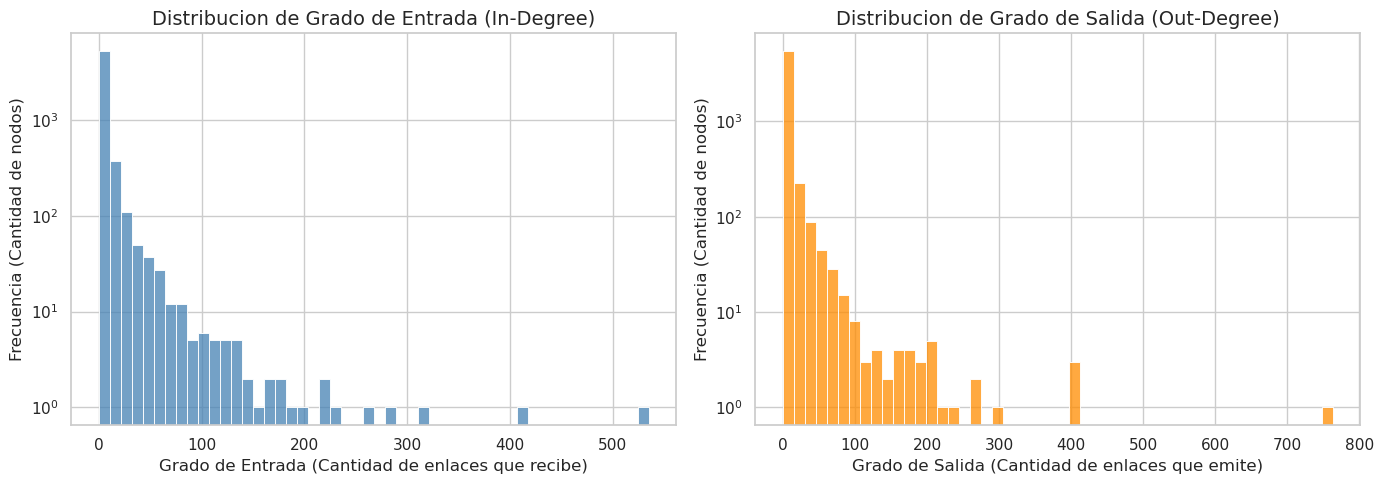

In [5]:
input_degre = [deg for node , deg in G.in_degree()]
output_degre = [deg for node , deg in G.out_degree()]

#grafico distribucion

sns.set_theme(style = "whitegrid")
fig , axes = plt.subplots(1 , 2 , figsize = (14 , 5))

sns.histplot(input_degre, bins=50, ax=axes[0], color='steelblue', kde=False)
axes[0].set_title("Distribucion de Grado de Entrada (In-Degree)", fontsize=14)
axes[0].set_xlabel("Grado de Entrada (Cantidad de enlaces que recibe)", fontsize=12)
axes[0].set_ylabel("Frecuencia (Cantidad de nodos)", fontsize=12)
axes[0].set_yscale('log') 
sns.histplot(output_degre, bins=50, ax=axes[1], color='darkorange', kde=False)
axes[1].set_title("Distribucion de Grado de Salida (Out-Degree)", fontsize=14)
axes[1].set_xlabel("Grado de Salida (Cantidad de enlaces que emite)", fontsize=12)
axes[1].set_ylabel("Frecuencia (Cantidad de nodos)", fontsize=12)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## b ) dentificacion y conteo de los nodos colgantes (nodos con grado de salida cero). Expliquen por que su presencia es problem ́atica para el PageRank ycomo se resuelve con la matriz columna-estocastica S.

In [6]:
nodos_colgantes = [nodo for nodo , output_grados in G.out_degree() if output_grados == 0]

cantidad_colgantes = len(nodos_colgantes)
total_nodos = (G.number_of_nodes())
porcentajes = round((cantidad_colgantes / total_nodos) * 100  , 2)

print(f"Total de nodos en el grafo: {total_nodos}")
print(f"Cantidad de nodos colgantes: {cantidad_colgantes}")
print(f"porcentaje de nodos colgantes: {porcentajes} ")

Total de nodos en el grafo: 5881
Cantidad de nodos colgantes: 1067
porcentaje de nodos colgantes: 18.14 


### ¿Porque la precencia de nodos colgantes es problematica para la creacion de la page rank?

Page Rank modela la navegación por medio de "caminos aleatorios" buscando analizar su convergencia, en este sentido , si nuestro "Caminante aleatorio" llega a un nodo colgante (sin aristas de salida) se quedara atrapado, luego esto implica que la matriz no converge a nada. Por otro lado, si lo analizamos en términos matriciales, se tiene que la columna asociada a ese nodo en la matriz de hipervínculos $H$ poseerá únicamente 0, y por ende no será estocástica y haciendo que el algoritmo de iteración de potencias pierda probabilidades con cada iteración, impidiendo una convergencia a alguna distribución válida

### ¿Cómo se resuelve con la matriz columna-estocástica?

La solución para este problema es "Forzar" a que la matriz sea estocástica. Para esto vamos a sustituir la columna llena de 0 por vectores uniformes donde su entrada vale $1/n$ con n como la cantidad total de nodos. Esto significa que cuando nuestro elemento "caminante" llegue al nodo problemático, se teletransporta aleatoriamente a cualquier otro con cualquier otro nodo con igual probabilidad, permitiendo su convergencia y que la nueva matriz S sume a 1

## C ) Gráfico o tabla con los 10 nodos de mayor grado de entrada y los 10 nodos de mayor grado de salida. Si los nodos tienen nombres o etiquetas, inclúyanlos.

_________________ Top 10 nodos con mayor grado de entrada _________________


,nodo (ID),Grado de entrada
0,24,535
1,2572,412
2,1786,311
3,1981,279
4,946,264
5,4,226
6,4072,222
7,11,216
8,4090,203
9,8,191


_________________ Top 10 nodos con mayor grado de Salida _________________


,nodo (ID),Grado de Salida
0,24,763
1,2572,406
2,1786,404
3,2072,397
4,1981,293
5,946,264
6,4072,264
7,11,232
8,4,215
9,3033,212


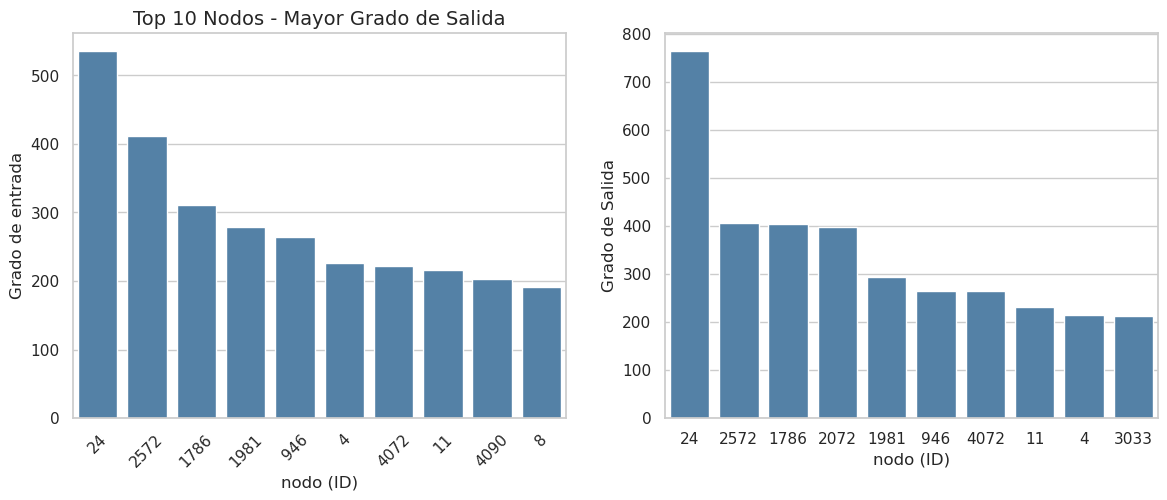

In [7]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

top_10_in = sorted(in_degree.items() , key = lambda x : x[1] , reverse=True)[:10]
top_10_out = sorted(out_degree.items() , key = lambda x : x[1] , reverse=True)[:10]

df_in = pd.DataFrame(top_10_in , columns=["nodo (ID)" , "Grado de entrada"])
df_out = pd.DataFrame(top_10_out , columns=["nodo (ID)" , "Grado de Salida"])
#tabla
print("_________________ Top 10 nodos con mayor grado de entrada _________________")
display(df_in)


print("_________________ Top 10 nodos con mayor grado de Salida _________________")
display(df_out)

#grafico
sns.set_theme(style="whitegrid")
fig , axes = plt.subplots(1 , 2 , figsize=(14 , 5))

#grafico input
sns.barplot(data = df_in , x = "nodo (ID)" , y = "Grado de entrada" , ax = axes[0] , color='steelblue', order = df_in["nodo (ID)"])
axes[0].set_title("Top 10 Nodos - Mayor Grado de Entrada", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
#grafico output
sns.barplot(data = df_out , x = "nodo (ID)" , y = "Grado de Salida" , ax = axes[1] , color='steelblue', order = df_out["nodo (ID)"])
axes[0].set_title("Top 10 Nodos - Mayor Grado de Salida", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)



In [8]:
ids_in = set(df_in['nodo (ID)'])
ids_out = set(df_out['nodo (ID)'])

nodos_comunes = ids_in.intersection(ids_out)
print(f"Los IDs de los nodos que aparecen en ambos Top 10 son: {nodos_comunes}")
print("luego podemos usar esto para verficar si estos elemtynos son los nodos con confianaza en la red de bitcoin  btw")

Los IDs de los nodos que aparecen en ambos Top 10 son: {'4', '2572', '946', '1786', '1981', '24', '11', '4072'}
luego podemos usar esto para verficar si estos elemtynos son los nodos con confianaza en la red de bitcoin  btw


## d ) Analizar conexidad de la red de bitcoin

In [9]:
es_conexa = nx.is_strongly_connected(G)

print(f"¿La red es fuertemente conexa? : {es_conexa}")

conexiones_conexas = nx.number_strongly_connected_components(G)
print(f"El numero de componentes que son fuertemente conexas son : {conexiones_conexas}")

componentes_fuertes = list(nx.strongly_connected_components(G))
tamanos_scc = [len(c) for c in componentes_fuertes]
tamanos_scc.sort(reverse= True)

print(f"el tamaño de la componente fuertemente conexa mas grande es : {tamanos_scc[0]} nodos")
print(f"cantidad de componentes compuetas por un solo nodo aislado : {tamanos_scc.count(1)}")
#analisis conexa si ignoramos direccion flechas
es_conexa_debil = nx.is_weakly_connected(G)
num_wcc = nx.number_weakly_connected_components(G)
print(f"¿la red es debilmente conexa (ignorando la direccion de los nodos)? : {es_conexa} ")
print(f"numero de componentes debilmente conexas : {num_wcc}" )


¿La red es fuertemente conexa? : False
El numero de componentes que son fuertemente conexas son : 1144
el tamaño de la componente fuertemente conexa mas grande es : 4709 nodos
cantidad de componentes compuetas por un solo nodo aislado : 1121
¿la red es debilmente conexa (ignorando la direccion de los nodos)? : False 
numero de componentes debilmente conexas : 4


Se puede notar que la red no es ni fuertemente conexa ni débilmente conexa, respecto a que la red no sea fuertemente conexa, esto era esperable, puesto que en la vida real es relativamente común que ciertas entidades depositen o hagan mucha transacción con nodos específicos y que esto no suceda en el caso contrario, a sí mismo que la red no sea débilmente conexa se puede explicar con la variabilidad y la forma en la que se hacen las transacciones, para ser débilmente conexa se esperaría que las transacciones se hagan de ambos lados (que 2 nodos se transfieran dinero de forma constante) cosa que no es esperable en la vida real

## p4

Crear la google matriz

(ejemplo en clase y tngo apuntes del mismo , cualquier cosa me preguntan)





In [10]:
#P4 (a) Construccion de la matriz de hipervinculos

nodos = list(G.nodes())
n = len(nodos)
nodos_idx = {nodo : i for i, nodo in enumerate(nodos)}
H_sparse = sparse.lil_matrix((n , n ))

for j_nodo in nodos:
    j = nodos_idx[j_nodo]
    out_deg = G.out_degree(j_nodo)

    if out_deg > 0:
        for i_nodo in G.successors(j_nodo):
            i = nodos_idx[i_nodo]
            H_sparse[i , j ] = 1.0 / out_deg
#pasar a matriz
H = H_sparse.toarray()

column_suma_H = H.sum(axis = 0)
columnas_cero = np.where(column_suma_H == 0)[0]

print(f"matriz h construida con las dimenciones {H.shape}")
print(f"Columnas cero encontradas : {len(columnas_cero)}")


matriz h construida con las dimenciones (5881, 5881)
Columnas cero encontradas : 1067


In [11]:
#p4 (b) construccion matriz estocastica S

a = np.zeros(n)
for j_nodo in nodos:
    j = nodos_idx[j_nodo]
    if G.out_degree(j_nodo) == 0 :
        a[j] = 1

S = H + (1.0 / n) * np.outer(np.ones(n) , a) #https://numpy.org/doc/stable/reference/generated/numpy.outer.html
columnas_suma_s = S.sum(axis = 0)
sumas_correctas= np.allclose(columnas_suma_s , 1.0) #allclose revisa si so similares en una distancia epsilon
print(f"todas las columnas de S suman 1 ? {sumas_correctas}" )

print(f"Suma mínima observada en columnas de S: {columnas_suma_s.min()}")
print(f"Suma máxima observada en columnas de S: {columnas_suma_s.max()}")


todas las columnas de S suman 1 ? True
Suma mínima observada en columnas de S: 0.9999999999999039
Suma máxima observada en columnas de S: 1.000000000000013


poodemos notar que el margen de error encontrado se corresponde con errores asociados al computo de numeros de coma flotante, y por tanto son validos con nuestros calculos

In [12]:
ALPHA = 0.85

M_ONES = np.ones((n , n)) 
G_MATRIX = ALPHA * S + ((1 - ALPHA) / n) * M_ONES

columna_suma_G = G_MATRIX.sum(axis = 0)
sumas_correctas_G = np.allclose(columna_suma_G , 1.0)
print(f"todas las columnas de G suman 1 ? {sumas_correctas_G}" )
print(f"Suma minima observada en columnas de G: {columna_suma_G.min()}")
print(f"Suma maxima observada en columnas de G: {columna_suma_G.max()}")
print(f"¿Todas las entradas de la Matriz G son positivas: ? {np.all(G_MATRIX > 0)}")
print(f"Entrada minima de la Matriz G: {G_MATRIX.min()}")

todas las columnas de G suman 1 ? True
Suma minima observada en columnas de G: 0.9999999999999039
Suma maxima observada en columnas de G: 1.0000000000002736
¿Todas las entradas de la Matriz G son positivas: ? True
Entrada minima de la Matriz G: 2.5505866349260334e-05


Como elección de $\alpha$ decidimos usar $\alpha = 0.85$ Este puesto que es el estándar de la industria, y puesto que según los análisis encontrados en el artículo https://archive.org/details/google-pagerank-algorithm-using-efficient-damping-factor/mode/1up es un buen número, este número equilibrio la influencia de la estructura con el "salto aleatorio $1 - \alpha$" de esta forma nos garantiza una convergencia rápida sin depender tanto de la forma especifica del gráfico
Por otro lado, las entradas deben de ser siempre positivas en nuestra matriz de Google, este puesto que si no nuestra matriz podría tener nodos que reciben un input sin liberar ningún output, cosa que tanto impediría la utilidad de la misma en ciertos contextos, y además, haría que la convergencia dependa del punto inicial de partida. Esto mismo no nos es útil, puesto que buscamos encontrar que nuestra matriz converja para cualquier punto $x_0$ elegido

## P5 

### P5(a): Iteración de potencias

Partimos del vector uniforme $\mathbf{r}^{(0)} = \mathbf{1}/n$ e iteramos

$$\mathbf{r}^{(k+1)} = G\,\mathbf{r}^{(k)}$$

hasta que $\|\mathbf{r}^{(k+1)} - \mathbf{r}^{(k)}\|_1 < \varepsilon = 10^{-10}$.

In [13]:
epsilon = 1e-10
max_iter = 10_000  # tope de seguridad

# Vector inicial uniforme
r = np.ones(n) / n

# Almacenar TODOS los r^(k) para calcular ||r^(k) - r*||_1 despues
historial_r = [r.copy()]
errores_sucesivos = []  # ||r^(k+1) - r^(k)||_1 para criterio de parada

for k in range(max_iter):
    r_nuevo = G_MATRIX @ r           # r^(k+1) = G * r^(k)
    error = np.sum(np.abs(r_nuevo - r))  # norma L1 de la diferencia sucesiva
    errores_sucesivos.append(error)
    r = r_nuevo
    historial_r.append(r.copy())
    if error < epsilon:
        break

num_iteraciones = len(errores_sucesivos)
r_star = r.copy()  # r* = vector estacionario convergido

# Calcular ||r^(k) - r*||_1 para cada iteracion
errores_vs_rstar = [np.sum(np.abs(rk - r_star)) for rk in historial_r]

print(f"Convergencia alcanzada en {num_iteraciones} iteraciones")
print(f"Error final ||r^(k+1) - r^(k)||_1: {errores_sucesivos[-1]:.2e}")
print(f"Error final ||r^(k) - r*||_1:       {errores_vs_rstar[-1]:.2e}")

Convergencia alcanzada en 107 iteraciones
Error final ||r^(k+1) - r^(k)||_1: 9.13e-11
Error final ||r^(k) - r*||_1:       0.00e+00


### P5(b): Curva de convergencia

Graficamos $\|\mathbf{r}^{(k+1)} - \mathbf{r}^{(k)}\|_1$ en escala logarítmica.  

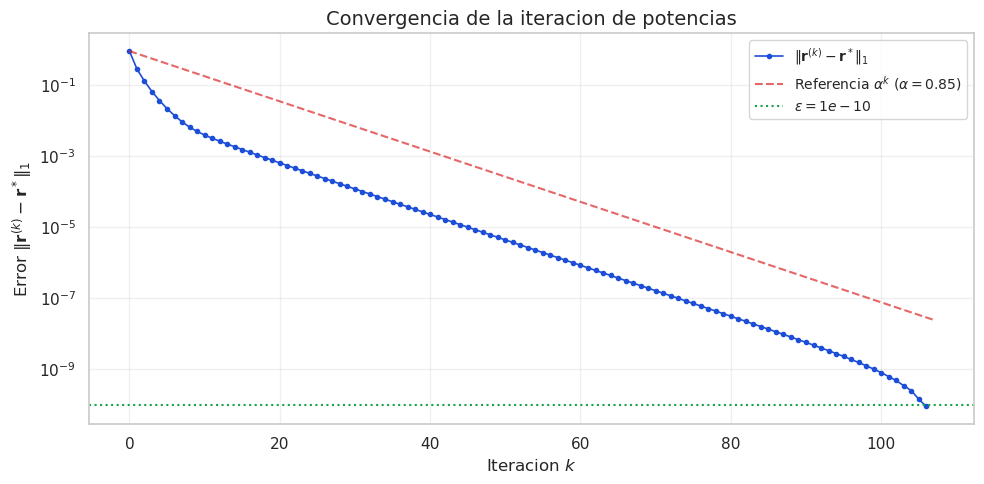

Razon media de decaimiento e_(k+1)/e_k (aprox) 0.8280
Valor teorico esperado (alpha)              = 0.85


In [14]:
# Grafico de convergencia (escala log)

fig, ax = plt.subplots(figsize=(10, 5))

# Graficar ||r^(k) - r*||_1
iters_rstar = np.arange(0, len(errores_vs_rstar))
# Excluir el ultimo punto si es 0 (para evitar problemas con log)
mask = np.array(errores_vs_rstar) > 0
ax.semilogy(iters_rstar[mask], np.array(errores_vs_rstar)[mask],
            marker='o', markersize=3, linewidth=1.2, color='#1d4ed8',
            label=r'$\|\mathbf{r}^{(k)} - \mathbf{r}^*\|_1$')

# Linea de referencia: decaimiento geometrico teorico alpha^k
referencia = errores_vs_rstar[0] * (ALPHA ** iters_rstar)
ax.semilogy(iters_rstar, referencia, '--', color='#dc2626', alpha=0.7,
            label=rf'Referencia $\alpha^k$ ($\alpha={ALPHA}$)')

ax.axhline(y=epsilon, color='#16a34a', linestyle=':', linewidth=1.5,
           label=rf'$\varepsilon = {epsilon:.0e}$')

ax.set_xlabel('Iteracion $k$', fontsize=12)
ax.set_ylabel(r'Error $\|\mathbf{r}^{(k)} - \mathbf{r}^*\|_1$', fontsize=12)
ax.set_title('Convergencia de la iteracion de potencias', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -- Verificar decaimiento geometrico --
# Calculamos la razon e_{k+1}/e_k usando ||r^(k) - r*||_1
ratios = [errores_vs_rstar[k+1] / errores_vs_rstar[k]
          for k in range(len(errores_vs_rstar) - 1)
          if errores_vs_rstar[k] > 0 and errores_vs_rstar[k+1] > 0]
ratio_medio = np.mean(ratios[5:])  # ignorar las primeras (transitorio)
print(f"Razon media de decaimiento e_(k+1)/e_k (aprox) {ratio_medio:.4f}")
print(f"Valor teorico esperado (alpha)              = {ALPHA}")

Se confirma el decaimiento geometrico con razon aprox. alpha

**Observacion sobre la curva:** El decaimiento es geometrico con razon $\approx \alpha = 0.85$ en la zona central del grafico (linea recta en escala log), confirmando la teoria. 
La curvatura al final se debe a que usamos como $\mathbf{r}^*$ la ultima iteracion computada y no el vector estacionario exacto: 
cuando $\mathbf{r}^{(k)}$ se acerca a $\mathbf{r}^{(k_{\text{final}})}$, la distancia colapsa artificialmente a cero por aritmetica de punto flotante.

### P5(c): Verificación de propiedades del vector estacionario TODO: corroborar

El teorema de Perron-Frobenius garantiza que, para una matriz columna-estocástica, irreducible y aperiódica (como la Matriz de Google $G$):

1. Existe un único vector propio $\mathbf{r}^*$ asociado al valor propio dominante $\lambda_1 = 1$.
2. Todas las componentes de $\mathbf{r}^*$ son estrictamente positivas: $r_i^* > 0 \; \forall i$.
3. Al normalizar $\|\mathbf{r}^*\|_1 = 1$, el vector representa una distribución de probabilidad (la distribución estacionaria del navegante aleatorio).

La irreducibilidad se asegura porque $G$ tiene todas sus entradas positivas (gracias al término de teletransportación $(1-\alpha)/n$), y una matriz con todas las entradas positivas es irreducible y aperiódica.

In [15]:
norma_l1 = np.sum(np.abs(r))
todas_positivas = np.all(r > 0)
min_componente = np.min(r)

print(f"||r*||_1 = {norma_l1:.15f}")
print(f"¿||r*||_1 ≈ 1?  → {np.isclose(norma_l1, 1.0)}")
print(f"")
print(f"¿Todas las componentes r_i* > 0?  → {todas_positivas}")
print(f"Componente mínima: {min_componente:.2e}")
print(f"Componente máxima: {np.max(r):.2e}")
print()
print("Esto se garantiza teóricamente por el Teorema de Perron-Frobenius:")
print("  • G es columna-estocástica (columnas suman 1)")
print("  • G es irreducible (todas las entradas son > 0 por la teletransportación)")
print("  • G es aperiódica (diagonal > 0)")
print("  ⟹ λ₁ = 1 es el único v.p. dominante, y el v.p. asociado r* tiene r_i* > 0 ∀i")

||r*||_1 = 1.000000000000002
¿||r*||_1 ≈ 1?  → True

¿Todas las componentes r_i* > 0?  → True
Componente mínima: 3.50e-05
Componente máxima: 1.50e-02

Esto se garantiza teóricamente por el Teorema de Perron-Frobenius:
  • G es columna-estocástica (columnas suman 1)
  • G es irreducible (todas las entradas son > 0 por la teletransportación)
  • G es aperiódica (diagonal > 0)
  ⟹ λ₁ = 1 es el único v.p. dominante, y el v.p. asociado r* tiene r_i* > 0 ∀i


### P5(d): Top 20 nodos por PageRank

In [16]:
# Crear DataFrame con PageRank, grado de entrada y grado de salida
pagerank_data = []
for i, nodo in enumerate(nodos):
    pagerank_data.append({
        'Nodo': nodo,
        'PageRank (r)': r[i],
        'd_in': G.in_degree(nodo),
        'd_out': G.out_degree(nodo)
    })

df_pagerank = pd.DataFrame(pagerank_data)
df_pagerank = df_pagerank.sort_values('PageRank (r)', ascending=False).reset_index(drop=True)
df_pagerank.index = df_pagerank.index + 1  # rango empieza en 1
df_pagerank.index.name = 'Rango'

# Mostrar los 20 primeros
top20 = df_pagerank.head(20)
print("Top 20 nodos por PageRank:\n")
print(top20.to_string())

Top 20 nodos por PageRank:

       Nodo  PageRank (r)  d_in  d_out
Rango                                 
1        24      0.015023   535    763
2      2572      0.010767   412    406
3      1786      0.006968   311    404
4      1981      0.006755   279    293
5        11      0.005912   216    232
6       946      0.005366   264    264
7      1900      0.005083   165    169
8         4      0.005028   226    215
9      4072      0.004765   222    264
10     4090      0.004664   203    202
11        8      0.004281   191    210
12      968      0.004075   179    203
13     2072      0.003873   180    397
14     2239      0.003350   145    200
15      160      0.003346   115    127
16     3639      0.003230   129    133
17      500      0.003161   144    167
18     4170      0.003111   158    172
19     1295      0.003109   164    164
20     1847      0.002965   132    138


Dado que Bitcoin OTC es una plataforma de transacciones anónimas el datatset no incluía más que un número entero positivo para identificar cada nodo, ningún metadato.

## P6: PageRank vs. Grado de Entrada

### P6(a): Gráfico disperso y correlación de Pearson


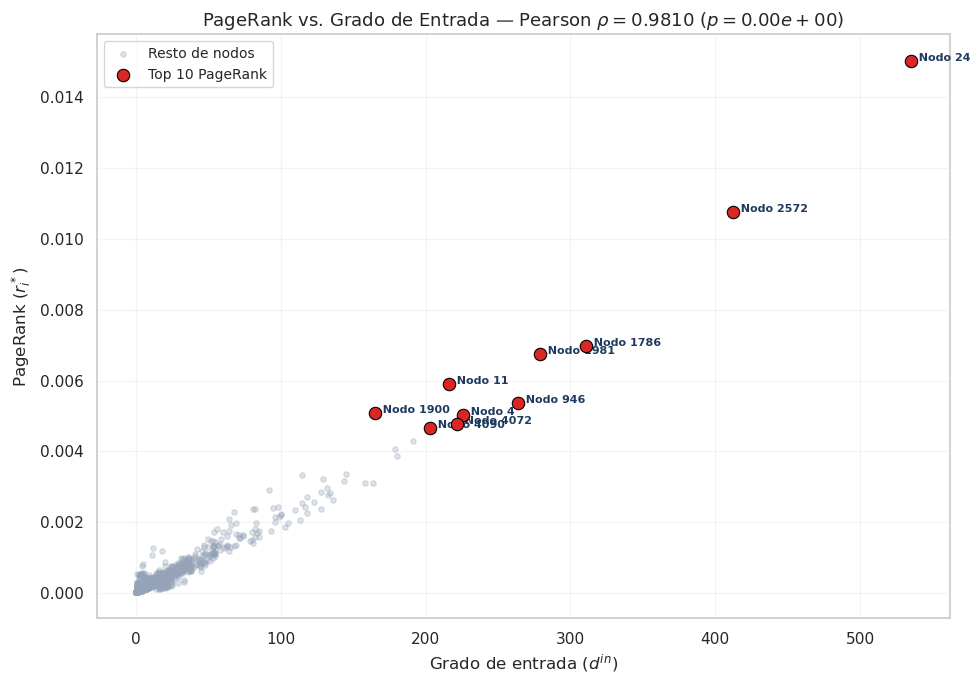

Coeficiente de correlación de Pearson: ρ = 0.9810
p-value: 0.00e+00


In [17]:
# -- P6(a): Grado de entrada vs PageRank --

from scipy.stats import pearsonr

# Usar el DataFrame de P5(d) que ya tiene PageRank, d_in, d_out
all_din = df_pagerank['d_in'].values
all_pr = df_pagerank['PageRank (r)'].values
all_nodos = df_pagerank['Nodo'].values

# Top 10 por PageRank
top10_mask = np.zeros(len(df_pagerank), dtype=bool)
top10_mask[:10] = True

# Coeficiente de Pearson
corr, p_value = pearsonr(all_din, all_pr)

# -- Gráfico --
fig, ax = plt.subplots(figsize=(10, 7))

# Todos los nodos (gris)
ax.scatter(all_din[~top10_mask], all_pr[~top10_mask],
           alpha=0.3, s=15, color='#94a3b8', label='Resto de nodos')

# Top 10 (destacados)
ax.scatter(all_din[top10_mask], all_pr[top10_mask],
           s=80, color='#dc2626', edgecolors='black', linewidths=0.8,
           zorder=5, label='Top 10 PageRank')

# Anotar top 10
for i in range(10):
    ax.annotate(f'  Nodo {all_nodos[i]}',
                (all_din[i], all_pr[i]),
                fontsize=8, fontweight='bold', color='#1e3a5f')

ax.set_xlabel('Grado de entrada ($d^{in}$)', fontsize=12)
ax.set_ylabel('PageRank ($r_i^*$)', fontsize=12)
ax.set_title(f'PageRank vs. Grado de Entrada — Pearson $\\rho = {corr:.4f}$ ($p = {p_value:.2e}$)',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Coeficiente de correlación de Pearson: ρ = {corr:.4f}")
print(f"p-value: {p_value:.2e}")


### P6(b): Nodos donde PageRank y grado de entrada difieren

In [18]:
# -- P6(b): Identificar nodos con discrepancia PageRank vs d_in --

df_disc = df_pagerank.copy()
n_nodos = len(df_disc)

# ── PASO 1: Asignar "Dense Ranks" ───────────────────────────────────────────
# Redondeamos a 5 decimales para crear empates (niveles de densidad) en PageRank
df_disc['pr_agrupado'] = df_disc['PageRank (r)'].round(5)
df_disc['rango_pr'] = df_disc['pr_agrupado'].rank(method='dense', ascending=False).astype(int)
df_disc['rango_din'] = df_disc['d_in'].rank(method='dense', ascending=False).astype(int)

# ── PASO 2: Escalar a un "Score" de 0 a 100 ─────────────────────────────────
max_r_pr  = df_disc['rango_pr'].max()
max_r_din = df_disc['rango_din'].max()

df_disc['score_pr']  = 100 * (max_r_pr - df_disc['rango_pr'])   / (max_r_pr - 1)
df_disc['score_din'] = 100 * (max_r_din - df_disc['rango_din']) / (max_r_din - 1)

# ── EXTRACCIÓN DE DATOS PARA VISUALIZACIÓN ──────────────────────────────────
pr_sorted = np.sort(df_disc['PageRank (r)'].values)[::-1]
din_sorted = np.sort(df_disc['d_in'].values)[::-1]

# Como df_disc ya viene ordenado por PageRank, sus scores están alineados con pr_sorted
score_dense_pr = df_disc['score_pr'].values

# Para d_in, re-ordenamos temporalmente para asegurar que los scores coincidan con din_sorted
df_din_sorted = df_disc.sort_values('d_in', ascending=False)
score_dense_din = df_din_sorted['score_din'].values


# ── PASO 3: Calcular la discrepancia ────────────────────────────────────────
df_disc['discrepancia'] = df_disc['score_pr'] - df_disc['score_din']

# ── Resultados ──────────────────────────────────────────────────────────────
caso_alto_pr  = df_disc.sort_values('discrepancia', ascending=False).head(5)
caso_alto_din = df_disc.sort_values('discrepancia', ascending=True).head(5)

cols = ['Nodo', 'PageRank (r)', 'd_in', 'd_out',
        'score_pr', 'score_din', 'discrepancia']

print("=" * 85)
print("CASO 1: PageRank ALTO pero d_in MODERADO/BAJO (Discrepancia Positiva)")
print("(pocos enlaces entrantes, pero de nodos muy importantes)")
print("=" * 85)
print(caso_alto_pr[cols].to_string(float_format='%.2f'))

print()
print("=" * 85)
print("CASO 2: d_in ALTO pero PageRank BAJO (Discrepancia Negativa)")
print("(muchos enlaces entrantes, pero de nodos poco importantes)")
print("=" * 85)
print(caso_alto_din[cols].to_string(float_format='%.2f'))


CASO 1: PageRank ALTO pero d_in MODERADO/BAJO (Discrepancia Positiva)
(pocos enlaces entrantes, pero de nodos muy importantes)
       Nodo  PageRank (r)  d_in  d_out  score_pr  score_din  discrepancia
Rango                                                                    
94     2496          0.00    12      7     59.57      10.34         49.23
113    1030          0.00    11     11     53.19       9.48         43.71
99      524          0.00    18     19     57.45      15.52         41.93
152    2629          0.00     5      1     41.49       4.31         37.18
176    2630          0.00     4      1     38.30       3.45         34.85

CASO 2: d_in ALTO pero PageRank BAJO (Discrepancia Negativa)
(muchos enlaces entrantes, pero de nodos poco importantes)
       Nodo  PageRank (r)  d_in  d_out  score_pr  score_din  discrepancia
Rango                                                                    
580    4556          0.00    33     11     14.36      28.45        -14.09
978    4546 

- **CASO 1:** Los nodos **2496** y **1030** tienen grados de entrada aceptables (12 y 11 conexiones). Sin embargo, PageRank dispara su valoración jerárquica (Score PR ~53-59). Esto indica que gozan de la confianza de la élite de la red; reciben pocas calificaciones, pero muy valiosas.
- **CASO 2:** Los nodos **4556** o el **4546** lograron acumular bastantes enlaces (33 y 24) (Score $d^{in}$ ~20-28). No obstante, PageRank los castiga (Score PR ~8-14) porque sus conexiones probablemente provienen en su mayoría de usuarios periféricos o recién llegados. Inflaron sus números, pero carecen de influencia real en Bitcoin OTC.

### ¿Por qué se uso `method='dense'` (Dense Ranking)?

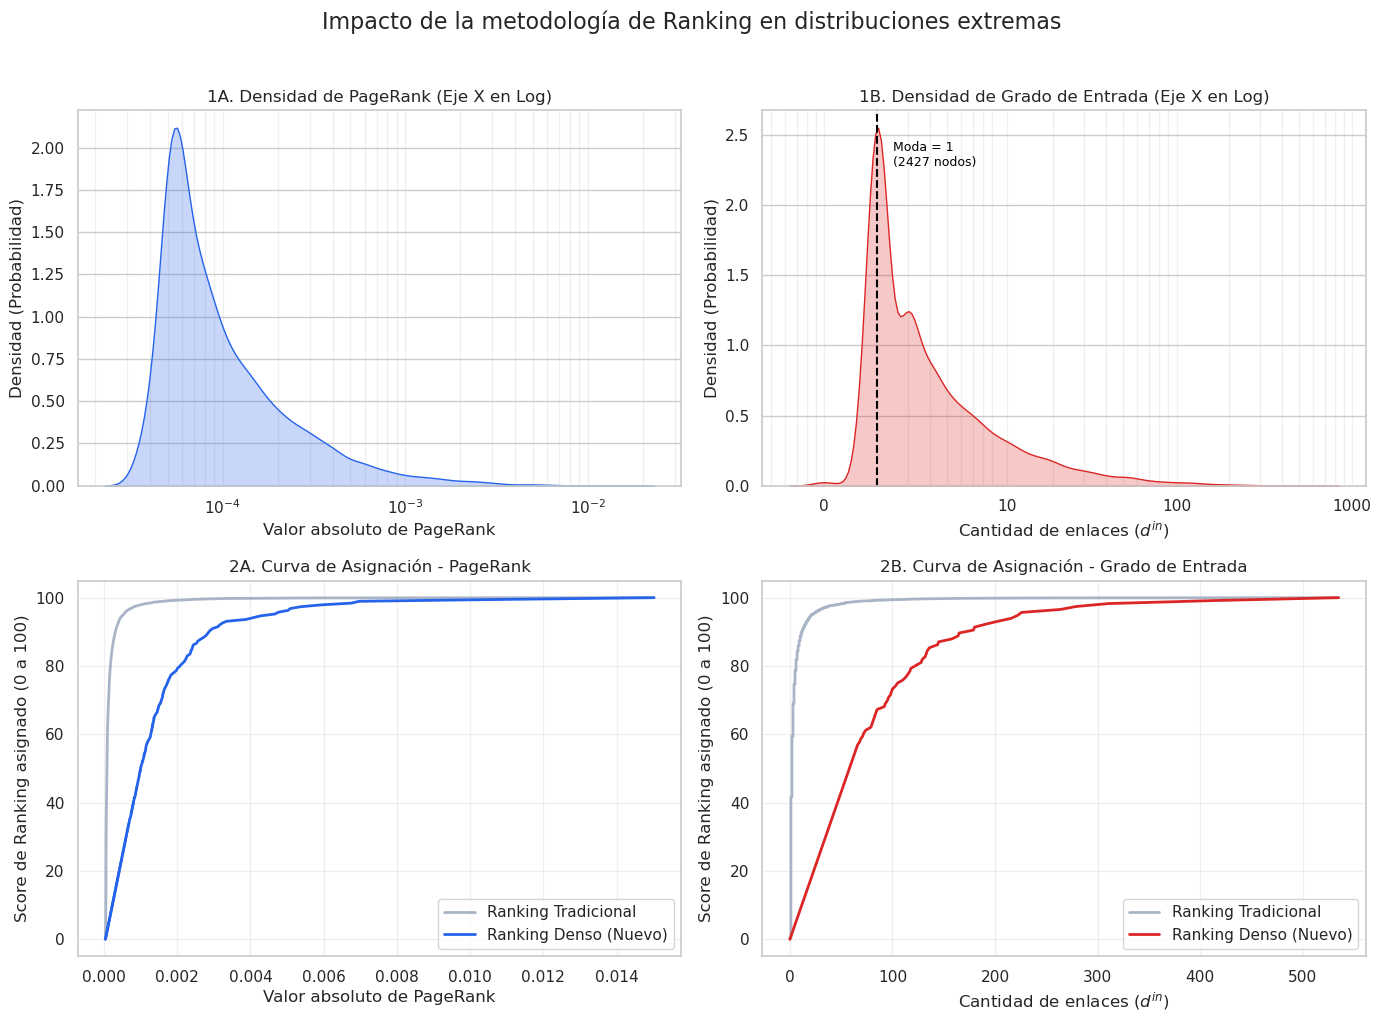

In [19]:
# -- Visualización de distribuciones sesgadas --
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Generar el Ranking Tradicional Posicional (Score 0-100 calculado linealmente por posición)
x_ranks = np.arange(1, n_nodos + 1)
score_trad = 100 * (n_nodos - x_ranks) / (n_nodos - 1)

# ── Fila 1: Curvas de Densidad (KDE) ──
# 1A. PageRank
sns.kdeplot(pr_sorted, ax=axes[0,0], fill=True, color='#2563eb', log_scale=(True, False))
axes[0,0].set_title("1A. Densidad de PageRank (Eje X en Log)")
axes[0,0].set_xlabel("Valor absoluto de PageRank")
axes[0,0].set_ylabel("Densidad (Probabilidad)")
axes[0,0].grid(True, which='both', axis='x', alpha=0.3) 

# 1B. d_in
sns.kdeplot(din_sorted + 1, ax=axes[0,1], fill=True, color='#dc2626', log_scale=(True, False))
axes[0,1].set_title("1B. Densidad de Grado de Entrada (Eje X en Log)")
axes[0,1].set_xlabel("Cantidad de enlaces ($d^{in}$)")
axes[0,1].set_ylabel("Densidad (Probabilidad)")

axes[0,1].set_xticks([1, 11, 101, 1001])
axes[0,1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x-1)}"))
axes[0,1].xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 1.0))
axes[0,1].grid(True, which='both', axis='x', alpha=0.3)

nodos_moda = (df_pagerank['d_in'] == 1).sum()
axes[0,1].axvline(2, color='black', linestyle='--', linewidth=1.5)
axes[0,1].text(2.1, axes[0,1].get_ylim()[1]*0.85, f'   Moda = 1\n   ({nodos_moda} nodos)', color='black', fontsize=9)


# ── Fila 2: Relación Valor vs. Asignación de Ranking ──
# 2A. PageRank
axes[1,0].plot(pr_sorted, score_trad, color='#94a3b8', linewidth=2, label='Ranking Tradicional', alpha=0.8)
axes[1,0].plot(pr_sorted, score_dense_pr, color='#2563eb', linewidth=2, label='Ranking Denso (Nuevo)')
axes[1,0].set_title("2A. Curva de Asignación - PageRank")
axes[1,0].set_ylabel("Score de Ranking asignado (0 a 100)")
axes[1,0].set_xlabel("Valor absoluto de PageRank")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# 2B. d_in
axes[1,1].plot(din_sorted, score_trad, color='#94a3b8', linewidth=2, label='Ranking Tradicional', alpha=0.8)
axes[1,1].plot(din_sorted, score_dense_din, color='#dc2626', linewidth=2, label='Ranking Denso (Nuevo)')
axes[1,1].set_title("2B. Curva de Asignación - Grado de Entrada")
axes[1,1].set_ylabel("Score de Ranking asignado (0 a 100)")
axes[1,1].set_xlabel("Cantidad de enlaces ($d^{in}$)")
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

plt.suptitle("Impacto de la metodología de Ranking en distribuciones extremas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Los gráficos revelan una desigualdad notable en la red. Los gráficos de densidad (KDE) muestran una acumulación gigantesca en valores mínimos; la mayor concentración de la red está exactamente en $d^{in} = 1$, agrupando a 2427 nodos (41.3% de los usuarios). 

Esta asimetría invalida la comparación directa, ya que la mayoría de la red colapsaría a un puntaje de `0`.

**El Problema del Ranking Tradicional**  
Para evidenciar esto, definimos un Score Tradicional (0 a 100) calculado linealmente según la posición absoluta del nodo (donde el 1° lugar absoluto = 100, y el lugar 5881 = 0). 

Como se aprecia en las Curvas de Asignación (Fila 2), este método no es óptimo para $d^{in}$ (gráfico 2B). La línea gris dibuja "acantilados" completamente verticales: al haber 2427 nodos empatados en $d^{in} = 1$, el sistema los ordena por posiciones arbitrarias continuas, haciendo que su score se desplome desde ~40 hasta casi 0.

**La Solución: Ranking Denso (Nuevo Score)**
Para hacer ambas métricas estadísticamente comparables, aplicamos un ranking `dense` (curvas a color en la fila 2). Este método ignora el volumen de empates y asigna un "Nivel" único a cada valor en la red. 

*(Ejemplo con 7 datos fuertemente sesgados: `[500, 2, 1, 1, 1, 0, 0]`)*
- **Score Tradicional (0-100 por posición):** Se calcula linealmente usando la posición absoluta del 1° al 7° lugar. Los puntajes quedarían así:
  - El `500` recibe **100.0**
  - El `2` recibe **83.3**
  - Los tres `1` reciben **66.7**, **50.0** y **33.3** respectivamente (una caída vertical para exactamente el mismo valor).
  - Los dos `0` reciben **16.7** y **0.0**.

- **Score Denso (0-100 por niveles únicos):** Existen solo 4 valores únicos en la red, por lo que se crean 4 escalones equitativos:
  - El `500` recibe **100.0**
  - El `2` recibe **66.7**
  - **Todos** los `1` reciben exactamente el mismo score de **33.3**.
  - **Todos** los `0` reciben exactamente el mismo score de **0.0**.


Aplicamos esta misma lógica a ambas métricas:
- **Para el Grado de Entrada:** Garantiza que los 2427 nodos con $d^{in} = 1$ reciban exactamente el mismo Score Denso (la línea escalonada roja en 2B).
- **Para PageRank:** Al ser una variable flotante, PageRank carece de empates naturales; micro-diferencias irrelevantes de $10^{-7}$ separarían nodos por cientos de posiciones (la violenta caída gris al final del gráfico 2A). Para solucionarlo, redondeamos PageRank a 5 decimales. Esto filtra el ruido y crea niveles de densidad artificiales parecidos a los de $d^{in}$, estabilizando más la curva (línea azul en 2A).

Al escalar estos "Niveles Densos" de 0 a 100, evaluamos equitativamente qué peldaño ocupa realmente cada nodo sin las deformaciones de los empates masivos.




## p7

Interpretar los resultados ,explicar como funcionea, que significa los datos

hacer un subgrado por los 50 nodos mas importantes , si existen ciertos atributos a cada grafo , ponerlos tambien

si la red tiene nodos dedistintas categorias, clasificarlos en cada una

## P7: Interpretación de resultados

En esta seccion buscamos interpretar la Page rank calculada en el contexto de Bitcoin. En este sentido debemos mencionar, que nuestra red es es *firmada*(ratings de -10 a + 10) pero al momento de construir $H$ nosotros unicamente usamos la existencia de esta arista $j \to i$ , no su signo, es decir, que nuestra page rank calculada da un "voto" a un nodo por cada que alguien lo califica, sea con ujna calificacion posiutiva op negativa, luego antes de decir "los nodos con mayor page rank son los mas confiable" . nos es de utilidad revisar el signo de sus calificaciones, esto puesto que un page rank alto puede significar tanto un usuario con calificaciones excelentes como uno muy denunciado o polemico

### a) Nodos con mayor Pagerank e interpretacion del dominio

Para interpretar en este sentido el ranking, vamos a alimentar nuestro Pagerak con el rating promedio percivido de cada nodo (El promedio de sus aristas entradas) justo con la fraccion de calificaciones negativas, buscando crear un top-page rank entre usuarios con reputaciones consolidadas y filtrando a los usuarios que son "Importante" por sus conexiones negativas entre los demas

In [22]:
confianza = []
for nodo in nodos:
    in_edge = G.in_edges(nodo, data=True)
    peso = [d["weight"] for _, _, d in in_edge]
    if len(peso) > 0:
        rate = (np.mean(peso))
        fraccion = np.mean([p < 0 for p in peso])
    else:
        rate = np.nan
        fraccion = np.nan
    confianza.append({
        "Nodo": nodo,
        "rating_prom_recibidos": rate,
        "fraccion_negativas_recibidos": fraccion,
        "Cantidad_rating_recibidos": len(peso)
    })

df_confianza = pd.DataFrame(confianza)

df = df_pagerank.merge(df_confianza, left_on='Nodo', right_on='Nodo', how='left')
df = df.sort_values('PageRank (r)', ascending=False).reset_index(drop=True)
df.index = df.index + 1  
df.index.name = 'Rango'

columnas_interes = ["Nodo", "PageRank (r)", "d_in", "d_out", "rating_prom_recibidos", "fraccion_negativas_recibidos", "Cantidad_rating_recibidos"] 


Top_20_preg_7 = df[columnas_interes].head(20)
print("Top 20 nodos por PageRank con métricas de confianza:\n")
print(Top_20_preg_7.to_string(float_format='%.2f'))

Top 20 nodos por PageRank con métricas de confianza:

       Nodo  PageRank (r)  d_in  d_out  rating_prom_recibidos  fraccion_negativas_recibidos  Cantidad_rating_recibidos
Rango                                                                                                                 
1        24          0.02   535    763                   1.90                          0.00                        535
2      2572          0.01   412    406                   2.53                          0.00                        412
3      1786          0.01   311    404                   0.74                          0.13                        311
4      1981          0.01   279    293                   0.72                          0.16                        279
5        11          0.01   216    232                   2.84                          0.00                        216
6       946          0.01   264    264                   0.61                          0.14                      

**Interpretaciones:**

Podemos notar que ningún nodo de nuestro top 20 presenta un grado de ser "sospechoso" , todos presentan un `rating_prom_recibido` positivo de entre 0.61 a 3.54 en la escala de -10 a 10 y una `fraccion_negativas_recibidos` baja de entre 0% a un 16% estos nos dice:

Estos nodos son un hub de actividad. En especial en nodo 24 el cual lidera con diferencia ($d_{in} = 535$ , $d_{out} = 763$) esto se entiende como alguien con mucho tiempo operando, y que califica y es calificado de forma masiva, con reputaciones positivas, hay otro caso como el 4(rating de 3.54) o el 11 (rating de 2.84) que poseen menos volumen, pero un mejor promedio, en general podemos notar que el top 20 son usuarios con cientos de calificaciones. La mayoría buenas.

Podemos notar entonces que el algoritmo no busca premiar a quienes reciben más calificaciones en bruto, sino que a quien es respaldado por la comunidad, de esta forma este grupo resulto que es el núcleo de traders confiables. Esto contrasta con nuestra hipótesis inicial de: EL pageRank estándar no está aislando a los actores de Desconfianza, sino que está identificado y uniendo a los usuarios más respaldados de la plataforma

## b): Sub grafo inducido con los nodos de mayor PageRank

Visualizaremos el sub grafo inducido por los 40 nodos de mayor PageRank. En este sentido nosotros no poseemos de atributos categóricos naturales(usuarios anónimos, id ,entre otros) es por esto que usaremos como atributo para unir los nodos el rating de confianza construido anteriormente, de forma que los nodos en verdes serán confiables, y los nodos en rojos eran los sospechosos / Denunciables.

subgrafo usando los 40 nodos con mayor grafo 
Tenemos 40 nodos y 641 aristas


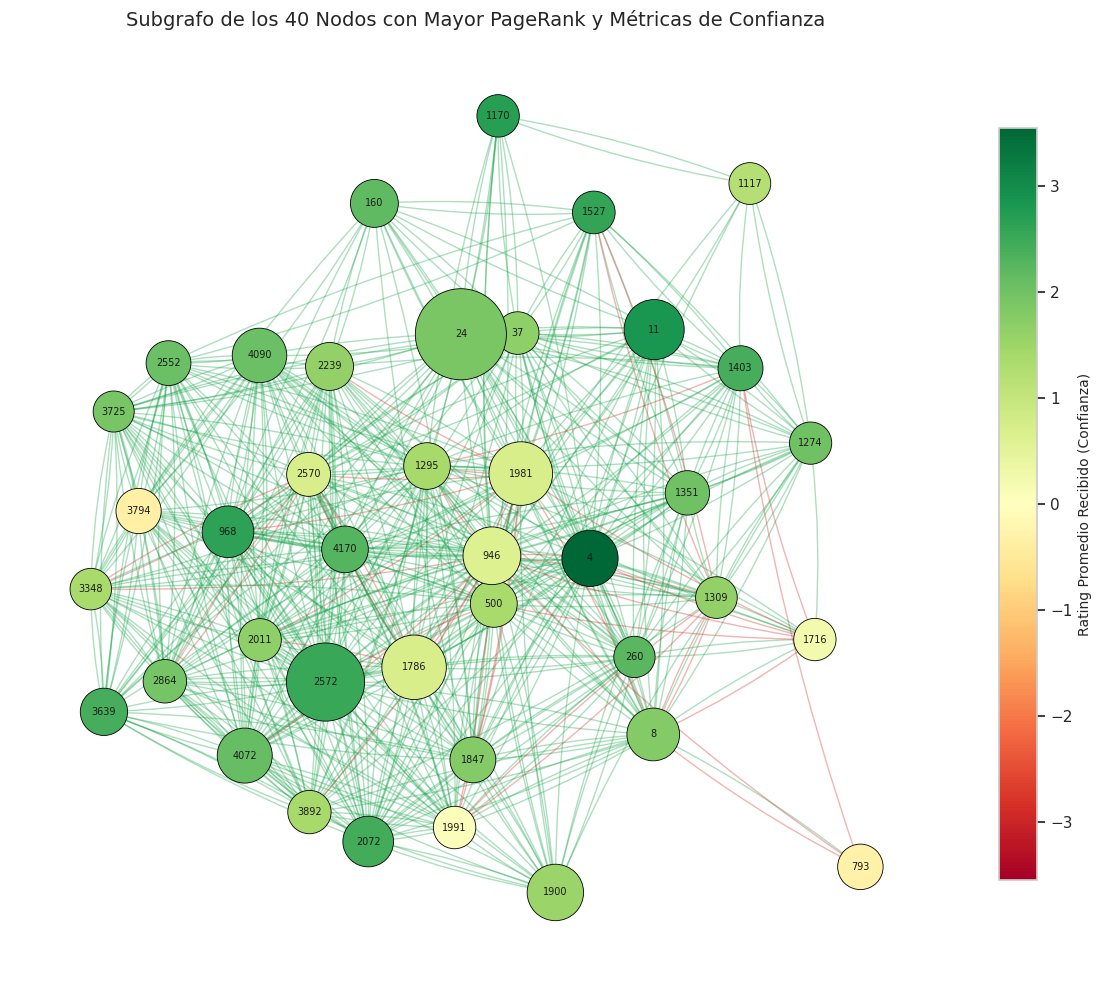

In [26]:
TOP_GRAFOS = 40
top_nodos = df.head(TOP_GRAFOS)['Nodo'].tolist()
subG = G.subgraph(top_nodos).copy()
print(f"subgrafo usando los {TOP_GRAFOS} nodos con mayor grafo \nTenemos {subG.number_of_nodes()} nodos y {subG.number_of_edges()} aristas")

pr_map = dict(zip(df['Nodo'], df['PageRank (r)']))
mapeo_confianza = dict(zip(df['Nodo'], df['rating_prom_recibidos']))
pr_max = df['PageRank (r)'].max()
#se hizo uso de claude para la creacion de este grafico btw
#No completo tipo, se modifico bastante el codigo para adaptarlo a nuestro caso de uso
tam_nodos = [300 + 4000 * (pr_map[nodo] / pr_max) for nodo in subG.nodes()]  
nodo_color = [mapeo_confianza[nodo] if not np.isnan(mapeo_confianza[nodo]) else 0 for nodo in subG.nodes()]
vmax = max(abs(min(nodo_color)) , abs(max(nodo_color)))
edge_colors = ['#16a34a' if d['weight'] >= 0 else '#dc2626' for _, _, d in subG.edges(data=True)]


fig , ax = plt.subplots(figsize=(12 , 10))
pos = nx.kamada_kawai_layout(subG,  weight=None)

nx.draw_networkx_edges(subG, pos, ax=ax, alpha=0.35, edge_color=edge_colors,
                        arrows=True, arrowsize=8, connectionstyle='arc3,rad=0.05')
nodes_drawn = nx.draw_networkx_nodes(subG, pos, ax=ax, node_size=tam_nodos,
                                      node_color=nodo_color, cmap='RdYlGn',
                                      vmin=-vmax, vmax=vmax,
                                      edgecolors='black', linewidths=0.6)
nx.draw_networkx_labels(subG, pos, ax=ax, font_size=7)

cbar = plt.colorbar(nodes_drawn, ax=ax, shrink=0.8)
cbar.set_label('Rating Promedio Recibido (Confianza)', fontsize=10)

ax.set_title(f'Subgrafo de los {TOP_GRAFOS} Nodos con Mayor PageRank y Métricas de Confianza', fontsize=14)
ax.axis('off')
plt.tight_layout()  
plt.show()

**Comentario de estructura observada**

Podemos notar que tenemos una estructura densa, similar a un "clúster" donde tenemos gran parte de los nodos interconectados entre sí, esto es consistente con lo que se vio anteriormente, un cúmulo de traders confiados conectados y que se califican simultáneamente.

Podemos notar además que como tal no existe ningún "nodo rojo". Hay nodos que reciben calificaciones negativas de otras, y nodos que se encuentran entre medio de una calificación positiva y negativa. Estos es consistente con lo visto anteriormente, no tenemos ningún "clúster de desconfianzas", todo Nuestro TOP-40 pertenece al mismo bloque de usuarios bien evaluados.

Además como nodo central tenemos al nodo 24, cosa coherente con los resultados anteriores , de igual forma los 4 y 11 son los que poseen un verde más oscuro, representando siu calidad, pero son notablemente más chicos (cosa ya vista en la tabla de resultados)

Tenemos además 4 nodos principales periféricos que están menos conectados, estos nodos parecen ser nodos que se "colaron" al top 40 sin estar integrados a la comunidad, se puede ver en general que están conectados a nodos de gran confianza o centrales.

Además , se puede notar una clara mayoría en las aristas positivas, en relación con las rojas que representan una mala calificación.



## C )¿Los nodos de mayor PageRank pertenecen a un grupo particular?

Nuestro grafo no posee ninguna tributo de nodo natural, únicamente id, es por esto que para responder nuestra pregunta usaremos como "grupo" la categoría de confianza derivada del rating de promedio recibido creado anteriormente, usando el rango confiable, neutral y sospechoso.

                     Top Grafos  Total
categoria_confianza                   
Rating alto                 2.5   9.05
Sin rating                  0.0   0.39
neutral                    92.5  76.13
sospechoso                  5.0  14.44


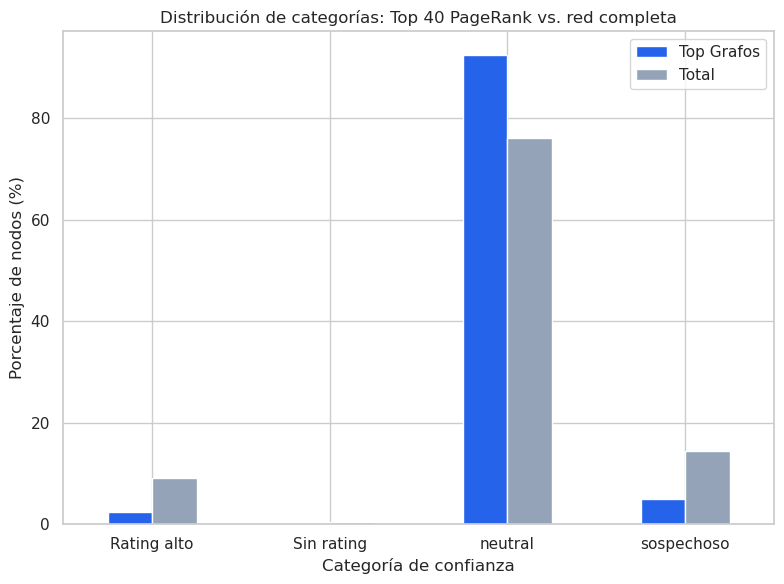

In [28]:
def categorizar(col):
    if pd.isna(col["rating_prom_recibidos"]):
        return "Sin rating"
    if col["rating_prom_recibidos"] >= 3:
        return "Rating alto"
    elif col["rating_prom_recibidos"] <= 0:
        return "sospechoso"
    else:
        return "neutral"
    

df['categoria_confianza'] = df.apply(categorizar, axis=1)
dist_top = df["categoria_confianza"].head(TOP_GRAFOS).value_counts(normalize=True).mul(100).round(2)
dist_total = df["categoria_confianza"].value_counts(normalize=True).mul(100).round(2)

comparaciones = pd.DataFrame({
    "Top Grafos": dist_top,
    "Total": dist_total
}).fillna(0)

print(comparaciones)

fig , ax = plt.subplots(figsize=(8, 6))
comparaciones.plot(kind='bar', ax=ax, color=['#2563eb', '#94a3b8'])
ax.set_ylabel('Porcentaje de nodos (%)')
ax.set_xlabel('Categoría de confianza')
ax.set_title(f'Distribución de categorías: Top {TOP_GRAFOS} PageRank vs. red completa')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretacion**

Al comparar las categorías de confianza entre el top 40 por PageRank podemos notar que el top 40  está fuertemente centrada en la categoría neutral, mientras que tanto en rating como sospechoso se tiene que está subrepresentado, esto indica que el alcanzar un page rank no depende necesariamente en tener la mejor reputación posible en promedio, sino de sostener un volumen alto de interacciones con una reputación lo suficientemente buena ,todos estos resultados son consistentes con los hallazgos de 7(a), como se notó con el caso del nodo 24. De todas formas los nodos Sospechosos del top 40 se encuentran sub representando , este puesto que se puede notar que en total hay una mayor cantidad de nodos sospechosos

P8: Discusión, limitaciones y conclusiones

Nuestra hipotesis planteada al inicio del proyecto sostenia que los estafadores dentro de una red de bitcoin OTC no operan de forma aislada, is no que se puede esperar una critica negativa entre ellos buscando inducir una falsa legitimidad, nuestra propuesta era que al aislar las aristas con peso negativo e invertir la dirreccion , el page rank revelaria una jerarquia oculta donde los nodos rankeados corresponderian a actores centrales del fraude.

Nuestra hipotesis no se cumplio en el analisis ejecutado. El page rank estandar construido sobre la erxistencia de aristas sin la consideraciopn del signo no identifico una red de desconfianza , ni algun tipo de dato de ese estilo . en este sentido se descuybvbrio exactamente lo contrario , podemos notar que los top 20 nodos con mayor page rank corresponden a los traders mas activos y evaludados de la plataforma tal que el nodo 24, el cual lidera el ranking con una gran diferencia encaja en nuestro perfil de usuario que califica y es calificado masivamente con una reputacion solida

Aun asi nuestro resultado no lo conasideramos un freacaso , si no una evidencia de que la PageRank en su version estandar captura la centralidad y el respaldo comunitario , no necesariamente caractericas negativas. el experimento

## p8

Explicar los resultados , las diferencias en la hipotesis , sus limitacio nes, resultados y demas

se deben de cumplir minimamente con las siguientes preguntas


¿La pregunta que formularon qued´o respondida con el an´alisis? ¿En qu´e
medida?
¿Qu´e limitaciones tiene PageRank para la red elegida? Por ejemplo: ¿tiene
sentido el modelo de marcha aleatoria? ¿los nodos colgantes son frecuentes
y afectan el resultado? ¿la red es demasiado densa o demasiado dispersa
para que PageRank sea informativo?
¿Qu´e preguntas nuevas surgieron del an´alisis que no anticiparon al co-
mienzo?
Si tuvieran que explicar el resultado principal a alguien sin conocimientos
t´ecnicos, ¿c´omo lo describir´ıan?

## se le pidio a una IA que de este mini check list de lo que debemos hacer

### Checklist de Entregables del Proyecto

* **P1: Elección y descripción de la red**
* [ ] Seleccionar una red dirigida de KONECT (mínimo 500 nodos y 2000 aristas).


* [ ] Describir el contexto, qué representan nodos/aristas y justificar la elección.


* [ ] Incluir tabla de estadísticas: $n$, $m$, $d^{in}$, $d^{out}$, nodo de mayor $d^{in}$, densidad y nodos colgantes.




* **P2: Pregunta e hipótesis inicial**
* [ ] Formular una pregunta concreta anclada al contexto de la red.


* [ ] Proponer una hipótesis sobre qué nodos tendrán mayor PageRank y justificarla (basada en dominio o exploración previa).




* **P3: Análisis exploratorio**
* [ ] Gráficos de distribución de grado de entrada y salida.


* [ ] Identificar/contar nodos colgantes y explicar su impacto matemático en la matriz $S$.


* [ ] Tabla o gráfico con los 10 nodos de mayor grado de entrada y salida (con sus etiquetas).


* [ ] Comentar sobre la conectividad de la red.




* **P4: Construcción de la Matriz de Google**
* [ ] Definir matriz de hipervínculos $H$ y explicar el manejo de columnas cero.


* [ ] Construir matriz estocástica $S$ reparando nodos colgantes.


* [ ] Construir matriz de Google $G$ justificando el parámetro $\alpha$.




* **P5: Cálculo mediante iteración de potencias**
* [ ] Implementar el algoritmo partiendo de $r^{(0)} = 1/n$ hasta alcanzar error $\epsilon < 10^{-10}$.


* [ ] Graficar curva de convergencia (escala logarítmica) y verificar decaimiento geométrico.


* [ ] Verificar que $||r^{*}||_{1}=1$ y $r_{i}^{*}>0$, explicando su garantía teórica.


* [ ] Presentar tabla con los 20 nodos de mayor PageRank (con rango, id, valor $r$, $d^{in}$ y $d^{out}$).




* **P6: PageRank vs. Grado de entrada**
* [ ] Graficar $d^{in}$ vs. PageRank (destacando top 10).


* [ ] Calcular coeficiente de correlación de Pearson.


* [ ] Identificar y analizar dos casos donde ambas métricas difieran significativamente.




* **P7: Interpretación de resultados**
* [ ] Explicar la influencia de los nodos top usando conocimiento del dominio.


* [ ] Visualizar el subgrafo de los 30-50 nodos más importantes (nodos escalados por PageRank y coloreados por atributo si aplica).


* [ ] Analizar si los nodos top pertenecen a grupos/atributos específicos.




* **P8: Discusión y conclusiones**
* [ ] Contrastar resultados con la hipótesis inicial.


* [ ] Responder si se respondió la pregunta inicial y discutir limitaciones (ej. modelo de marcha aleatoria, densidad de la red).


* [ ] Explicar el resultado principal en lenguaje no técnico.




* **Aspectos Técnicos y Formato**
* [ ] Repositorio en GitHub con instrucciones de ejecución y datos reproducibles.


* [ ] Informe final en .pdf (breve, claro y estructurado).


* [ ] Código principal en Python usando `numpy`, `scipy.sparse`, `networkx`, `matplotlib/seaborn`.
    